In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("final_full_datasetBACE1.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
df.head()

Molecule ChEMBL ID  \
0      CHEMBL4216412   
1      CHEMBL4204742   
2      CHEMBL1644466   
3      CHEMBL4062699   
4       CHEMBL522778   

                                                                                                      Smiles  \
0                                                Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2  COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                          CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   

   pChEMBL Value Activity  \
0           7.19   Active   
1           7.18   Active   
2           5.51   Active   
3           8.32   Active   
4           5.12   Active   

                                                                                            canonical_smiles  \
0                                                Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2  COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                          CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   

        MolWt     LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0  415.375000  3.36220       2.0          6.0  113.39                4.0   
1  397.385000  3.06660       2.0          6.0  113.39                4.0   
2  722.905000  4.03440       4.0          8.0  163.37               11.0   
3  423.940204  4.55038       1.0          5.0   80.63                2.0   
4  425.614000  2.80380       4.0          4.0  107.53                7.0   

   NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  \
0      30.0            30.0            10.0        20.0           5.0   
1      29.0            29.0             9.0        20.0           5.0   
2      51.0            51.0            13.0        38.0           4.0   
3      32.0            30.0             6.0        24.0           3.0   
4      30.0            30.0             7.0        23.0           3.0   

   NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  NumTripleBonds  \
0         2.0          3.0      32.0             3.0             1.0   
1         2.0          2.0      31.0             3.0             1.0   
2         8.0          0.0      54.0             5.0             0.0   
3         2.0          1.0      36.0             1.0             1.0   
4         4.0          0.0      30.0             3.0             0.0   

   NumRings  NumAromaticRings  NumAliphaticRings  NumSaturatedRings  \
0       3.0               2.0                1.0                0.0   
1       3.0               2.0                1.0                0.0   
2       4.0               3.0                1.0                0.0   
3       5.0               2.0                3.0                1.0   
4       1.0               0.0                1.0                1.0   

   NumAromaticAtoms  NumAliphaticAtoms  FractionCSP3  morgan_0  morgan_1  \
0              12.0               18.0      0.200000         0         1   
1              12.0               17.0      0.200000         0         0   
2              18.0               33.0      0.447368         0         1   
3              12.0               20.0      0.416667         0         0   
4               0.0               30.0      0.869565         0         1   

   morgan_2  morgan_3  morgan_4  morgan_5  morgan_6  morgan_7  morgan_8  \
0         0         0         0         0       

In [4]:
df.info()   # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7922 entries, 0 to 7921
Columns: 5148 entries, Molecule ChEMBL ID to rdk_2047
dtypes: float64(24), int64(5120), object(4)
memory usage: 311.1+ MB


In [5]:
df.shape   # No. of Features and Datapoints

(7922, 5148)

In [6]:
df = df[[c for c in df.columns if (
    'morgan' in c.lower() 
    or not any(fp in c.lower() for fp in ['rdk', 'atompair', 'maccs', 'pubchem'])
)]]

In [7]:
df

Molecule ChEMBL ID  \
0         CHEMBL4216412   
1         CHEMBL4204742   
2         CHEMBL1644466   
3         CHEMBL4062699   
4          CHEMBL522778   
...                 ...   
7917      CHEMBL6161637   
7918      CHEMBL6145969   
7919      CHEMBL5817550   
7920      CHEMBL6030218   
7921      CHEMBL6188525   

                                                                                                         Smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

      pChEMBL Value  Activity  \
0              7.19    Active   
1              7.18    Active   
2              5.51    Active   
3              8.32    Active   
4              5.12    Active   
...             ...       ...   
7917           6.60    Active   
7918           4.02  Inactive   
7919           9.39    Active   
7920           6.22    Active   
7921           4.71  Inactive   

                                                                                               canonical_smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

           MolWt     LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0     415.375000  3.36220       2.0          6.0  113.39                4.0   
1     397.385000  3.06660       2.0          6.0  113.39                4.0   
2     722.905000  4.03440       4.0          8.0  163.37               11.0   
3     423.940204  4.55038       1.0          5.0   80.63                2.0   
4     425.614000  2.80380       4.0          4.0  107.53                7.0   
...          ...      ...       ...          ..

# eliminating zeros

In [8]:
# Calculate sum of numeric features only
feature_sum = df.sum(numeric_only=True)

# Find features with sum = 0
zero_features = feature_sum[feature_sum == 0].index

# Remove those features
df = df.drop(columns=zero_features)

print("Removed columnsandronew:", len(zero_features))

Removed columnsandronew: 2


In [9]:
df

Molecule ChEMBL ID  \
0         CHEMBL4216412   
1         CHEMBL4204742   
2         CHEMBL1644466   
3         CHEMBL4062699   
4          CHEMBL522778   
...                 ...   
7917      CHEMBL6161637   
7918      CHEMBL6145969   
7919      CHEMBL5817550   
7920      CHEMBL6030218   
7921      CHEMBL6188525   

                                                                                                         Smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

      pChEMBL Value  Activity  \
0              7.19    Active   
1              7.18    Active   
2              5.51    Active   
3              8.32    Active   
4              5.12    Active   
...             ...       ...   
7917           6.60    Active   
7918           4.02  Inactive   
7919           9.39    Active   
7920           6.22    Active   
7921           4.71  Inactive   

                                                                                               canonical_smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

           MolWt     LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0     415.375000  3.36220       2.0          6.0  113.39                4.0   
1     397.385000  3.06660       2.0          6.0  113.39                4.0   
2     722.905000  4.03440       4.0          8.0  163.37               11.0   
3     423.940204  4.55038       1.0          5.0   80.63                2.0   
4     425.614000  2.80380       4.0          4.0  107.53                7.0   
...          ...      ...       ...          ..

# missing values

In [10]:
df.isnull().sum()

Molecule ChEMBL ID    0
Smiles                0
pChEMBL Value         0
Activity              0
canonical_smiles      0
                     ..
morgan_2043           0
morgan_2044           0
morgan_2045           0
morgan_2046           0
morgan_2047           0
Length: 2074, dtype: int64

In [11]:
print(df.shape)

(7922, 2074)


In [12]:
df = df.drop_duplicates(subset = ['Molecule ChEMBL ID', 'canonical_smiles'])

In [13]:
df.drop(['Molecule ChEMBL ID', 'canonical_smiles'], axis = 1, inplace = True)

In [14]:
df

Smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

      pChEMBL Value  Activity       MolWt     LogP  H_Donors  H_Acceptors  \
0              7.19    Active  415.375000  3.36220       2.0          6.0   
1              7.18    Active  397.385000  3.06660       2.0          6.0   
2              5.51    Active  722.905000  4.03440       4.0          8.0   
3              8.32    Active  423.940204  4.55038       1.0          5.0   
4              5.12    Active  425.614000  2.80380       4.0          4.0   
...             ...       ...         ...      ...       ...          ...   
7917           6.60    Active  417.340000  4.79760       1.0          5.0   
7918           4.02  Inactive  424.844000  3.02480       1.0          6.0   
7919           9.39    Active  537.571000  4.19930       1.0          9.0   
7920           6.22    Active  345.349000  2.31212       1.0          4.0   
7921           4.71  Inactive  453.454000  4.30840       1.0          7.0   

        TPSA  NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  \
0     113.39                4.0      30.0            30.0            10.0   
1     113.39                4.0      29.0            29.0             9.0   
2     163.37               11.0      51.0            51.0            13.0   
3      80.63                2.0      32.0            30.0             6.0   
4     107.53                7.0      30.0            30.0             7.0   
...      ...                ...       ...             ...             ...   
7917   54.19                6.0      28.0            28.0             7.0   
7918   99.25                6.0      30.0            30.0             9.0   
7919  113.31                5.0      38.0            38.0            12.0   
7920   67.92                3.0      25.0            25.0             7.0   
7921  125.42                2.0      34.0            34.0             8.0   

      NumCarbons  NumNitrogens  NumOxygens  NumHalogens  NumBonds  \
0           20.0           5.0         2.0          3.0      32.0   
1           20.0           5.0         2.0          2.0      31.0   
2           38.0           4.0         8.0          0.0      54.0   
3           24.0           3.0         2.0          1.0      36.0   
4           23.0           3.0         4.0          0.0      30.0   
...          ...           ...         ...          ...       ...   
7917        21.0           4.0         1.0          2.0      31.0   
7918        21.0           4.0         4.0          1.0      33.0   
7919        26.0           7.0         1.0          3.0      42.0   
7920        18.0           3.0         2.0          2.0      27.0   
7921        26.0           3.0         5.0          0.0      39.0   

      NumDoubleBonds  NumTripleBonds  NumRing

# label encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Activity"] = le.fit_transform(df["Activity"])

In [17]:
df['Activity'].value_counts()

Activity
0    7199
1     723
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

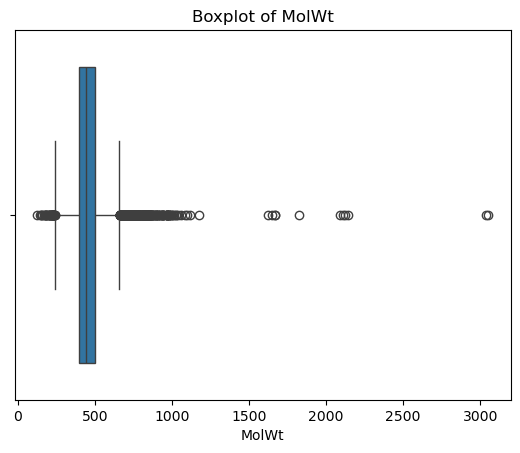

In [19]:
sns.boxplot (x =df ['MolWt'])
plt.title ("Boxplot of MolWt")
plt.show()

In [20]:
numeric_cols = ["MolWt", "LogP", "H_Acceptors","H_Donors", "TPSA","NumRotatableBonds"]

Outliers ={}
for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
         
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        
        Outliers[col]=df[(df[col]<lower)| (df[col]>upper)]
        
        print (f"{col} : {len(Outliers [col])} outlier detected")

MolWt : 459 outlier detected
LogP : 261 outlier detected
H_Acceptors : 116 outlier detected
H_Donors : 857 outlier detected
TPSA : 348 outlier detected
NumRotatableBonds : 586 outlier detected


# removing outliers

In [21]:
df = df[(df[col] >= lower) & (df[col] <= upper)]
df

Smiles  \
0                                                   Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(C(F)F)OC(N)=N2)c1   
1                                                      Cc1cc(C#N)cnc1C(=O)Nc1ccc(F)c([C@]2(C)C=C(CF)OC(N)=N2)c1   
2     COc1ccc(C2NC(=O)c3cc(cc(N(C)S(C)(=O)=O)c3)C(=O)N[C@H]([C@@H](O)C[C@H](C(=O)NCC(C)C)C(C)C)COCc3cccc2c3)cc1   
3                                   [2H]C1([2H])OC(N)=N[C@]12c1cc(-c3cc(Cl)cc(C#N)c3)ccc1C[C@]21CC[C@@H](OC)CC1   
4                                             CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]1CCCCCCCCCC(=O)N[C@@H](C)C(=O)N1   
...                                                                                                         ...   
7917                                                            Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1   
7918                                                            COc1cccc2cc(C(=O)NCc3cnnn3Cc3ccccc3Cl)c(=O)oc12   
7919                                COc1nc(N2C[C@H]3CSC(N)=N[C@@]3(c3cc(/C=C(\F)c4ccc(C#N)cn4)ccc3F)C2)nc(C)c1F   
7920                                                              COc1ccc(C2(c3cc(F)cc(F)c3)N=C(N)N(C)C2=O)cc1C   
7921                                       Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C(=O)c3ccccc3C1=O)CCCC2   

      pChEMBL Value  Activity       MolWt     LogP  H_Donors  H_Acceptors  \
0              7.19         0  415.375000  3.36220       2.0          6.0   
1              7.18         0  397.385000  3.06660       2.0          6.0   
2              5.51         0  722.905000  4.03440       4.0          8.0   
3              8.32         0  423.940204  4.55038       1.0          5.0   
4              5.12         0  425.614000  2.80380       4.0          4.0   
...             ...       ...         ...      ...       ...          ...   
7917           6.60         0  417.340000  4.79760       1.0          5.0   
7918           4.02         1  424.844000  3.02480       1.0          6.0   
7919           9.39         0  537.571000  4.19930       1.0          9.0   
7920           6.22         0  345.349000  2.31212       1.0          4.0   
7921           4.71         1  453.454000  4.30840       1.0          7.0   

        TPSA  NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  \
0     113.39                4.0      30.0            30.0            10.0   
1     113.39                4.0      29.0            29.0             9.0   
2     163.37               11.0      51.0            51.0            13.0   
3      80.63                2.0      32.0            30.0             6.0   
4     107.53                7.0      30.0            30.0             7.0   
...      ...                ...       ...             ...             ...   
7917   54.19                6.0      28.0            28.0             7.0   
7918   99.25                6.0      30.0            30.0             9.0   
7919  113.31                5.0      38.0            38.0            12.0   
7920   67.92                3.0      25.0            25.0             7.0   
7921  125.42                2.0      34.0            34.0             8.0   

      NumCarbons  NumNitrogens  NumOxygens  NumHalogens  NumBonds  \
0           20.0           5.0         2.0          3.0      32.0   
1           20.0           5.0         2.0          2.0      31.0   
2           38.0           4.0         8.0          0.0      54.0   
3           24.0           3.0         2.0          1.0      36.0   
4           23.0           3.0         4.0          0.0      30.0   
...          ...           ...         ...          ...       ...   
7917        21.0           4.0         1.0          2.0      31.0   
7918        21.0           4.0         4.0          1.0      33.0   
7919        26.0           7.0         1.0          3.0      42.0   
7920        18.0           3.0         2.0          2.0      27.0   
7921        26.0           3.0         5.0          0.0      39.0   

      NumDoubleBonds  NumTripleBonds  NumRing

# removing corelated factors

In [22]:
import numpy as np

# Columns that must NOT be used for correlation-based deletion
exclude_columns = [
    "Activity",
    "pChEMBL Value"
]

# Select only numeric columns except target and pChEMBL
numeric_df = df.select_dtypes(include=["number"]).drop(
    columns=exclude_columns,
    errors="ignore"
)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Store correlated features
correlated_features = set()

# Check only the upper triangle of correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.80:

            colname = correlation_matrix.columns[i]

            correlated_features.add(colname)


# Display results
print("Number of correlated features to remove:",
      len(correlated_features))

print("\nCorrelated features:")
print(correlated_features)

Number of correlated features to remove: 109

Correlated features:
{'morgan_1805', 'morgan_1253', 'morgan_873', 'NumCarbons', 'morgan_2033', 'morgan_1819', 'morgan_406', 'morgan_1495', 'morgan_1629', 'morgan_1928', 'morgan_170', 'morgan_1414', 'NumAtoms', 'morgan_790', 'morgan_1264', 'morgan_1983', 'morgan_1896', 'morgan_1753', 'morgan_1917', 'morgan_1384', 'morgan_1845', 'morgan_574', 'morgan_1746', 'morgan_2026', 'morgan_1108', 'morgan_270', 'morgan_1403', 'morgan_1828', 'morgan_837', 'NumBonds', 'morgan_1902', 'morgan_1631', 'morgan_670', 'morgan_519', 'morgan_970', 'morgan_1320', 'morgan_1863', 'morgan_665', 'morgan_1408', 'morgan_1618', 'morgan_1236', 'morgan_1548', 'morgan_1905', 'morgan_1621', 'morgan_651', 'morgan_1457', 'morgan_1979', 'morgan_1523', 'morgan_940', 'morgan_741', 'morgan_1376', 'morgan_630', 'morgan_1266', 'morgan_1136', 'morgan_364', 'morgan_1259', 'morgan_117', 'morgan_1644', 'morgan_1871', 'morgan_1540', 'morgan_1603', 'morgan_227', 'morgan_264', 'morgan_1884'

In [23]:
df.drop(
    columns=list(correlated_features),
    inplace=True
)

print("Correlated features removed successfully.")

print("New dataset shape:")
print(df.shape)

Correlated features removed successfully.
New dataset shape:
(7336, 1963)


C:\Users\sahan\AppData\Local\Temp\ipykernel_2064\1558483522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


# train and split

In [24]:
print(df.groupby("Activity")["pChEMBL Value"].agg(["min", "max", "count"]))

           min    max  count
Activity                    
0         5.00  10.96   6687
1         2.54   4.99    649


In [25]:
print(df["Activity"].value_counts())

Activity
0    6687
1     649
Name: count, dtype: int64


In [26]:
df["Activity"]

0       0
1       0
2       0
3       0
4       0
       ..
7917    0
7918    1
7919    0
7920    0
7921    1
Name: Activity, Length: 7336, dtype: int64

In [27]:
# Correct the activity labels

df["Activity"] = 1 - df["Activity"]

print(df["Activity"].value_counts())

Activity
1    6687
0     649
Name: count, dtype: int64


C:\Users\sahan\AppData\Local\Temp\ipykernel_2064\959254278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = 1 - df["Activity"]


In [28]:
print(
    df.groupby("Activity")["pChEMBL Value"]
      .agg(["min", "max", "count"])
)

           min    max  count
Activity                    
0         2.54   4.99    649
1         5.00  10.96   6687


In [29]:
df = df.copy()

In [30]:
# Features and target

X = df.drop(
    columns=["Activity", "pChEMBL Value"],
    errors="ignore"
)

y = df["Activity"]

# Keep only numerical ML features
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (7336, 1960)
y shape: (7336,)

Class distribution:
Activity
1    6687
0     649
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (5868, 1960)
X_test shape: (1468, 1960)

Training class distribution:
Activity
1    5349
0     519
Name: count, dtype: int64

Test class distribution:
Activity
1    1338
0     130
Name: count, dtype: int64


# smote analysis

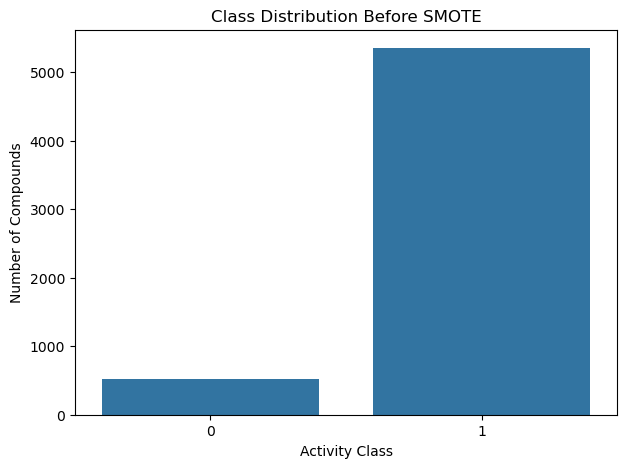

In [32]:
# Class distribution before SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution Before SMOTE")

plt.show()

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Activity
1    5349
0     519
Name: count, dtype: int64

After SMOTE:
Activity
1    5349
0    5349
Name: count, dtype: int64


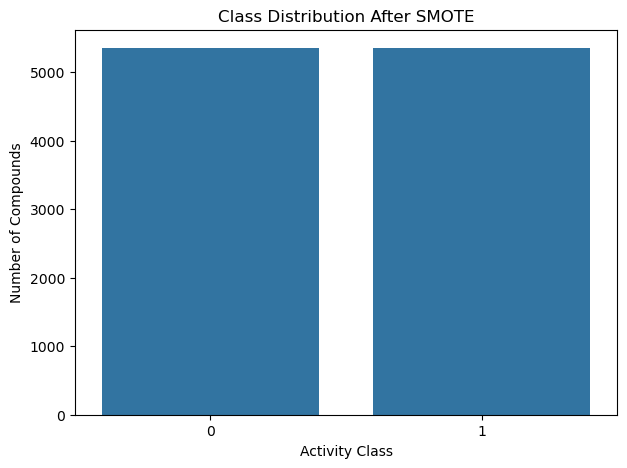

In [34]:
# Class distribution after SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution After SMOTE")

plt.show()

# logistic regression 

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

LR = LogisticRegression(max_iter=1000)

LR.fit(X_train_sm, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
LR_predict = LR.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, LR_predict))

print(classification_report(
    y_test,
    LR_predict,
    target_names=["Inactive", "Active"],
    digits=4
))

Accuracy_score = 0.9148501362397821
              precision    recall  f1-score   support

    Inactive     0.5197    0.5077    0.5136       130
      Active     0.9523    0.9544    0.9533      1338

    accuracy                         0.9149      1468
   macro avg     0.7360    0.7311    0.7335      1468
weighted avg     0.9140    0.9149    0.9144      1468



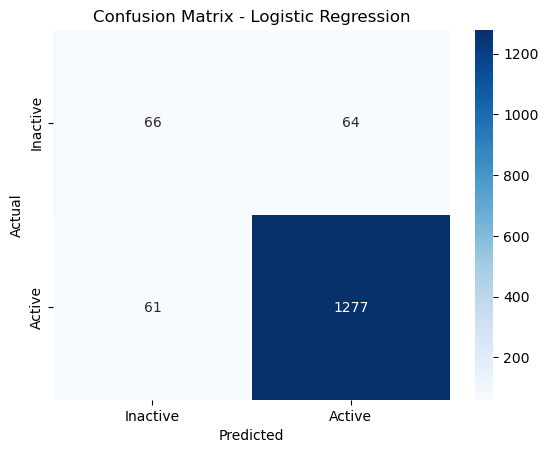

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, LR_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

LR ROC AUC = 0.842


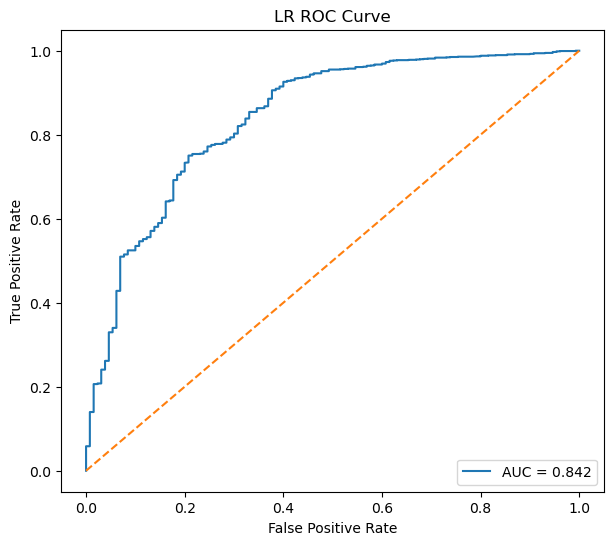

In [40]:
from sklearn.metrics import roc_curve, auc

LR_prob = LR.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    LR_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LR ROC Curve")

plt.legend(loc="lower right")

print("LR ROC AUC = %.3f" % roc_auc)

plt.show()

# decision tree 

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
DT = DecisionTreeClassifier(
    random_state=42
)

DT.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
DT_predict = DT.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, DT_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        DT_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.8985013623978202

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.4379    0.5154    0.4735       130
      Active     0.9521    0.9357    0.9438      1338

    accuracy                         0.8985      1468
   macro avg     0.6950    0.7256    0.7087      1468
weighted avg     0.9066    0.8985    0.9022      1468



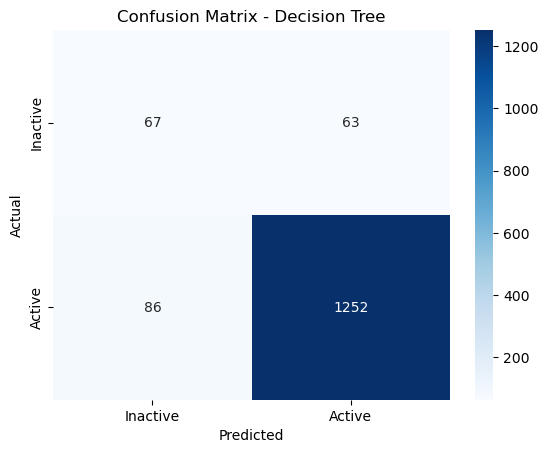

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    DT_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Decision Tree ROC AUC = 0.728


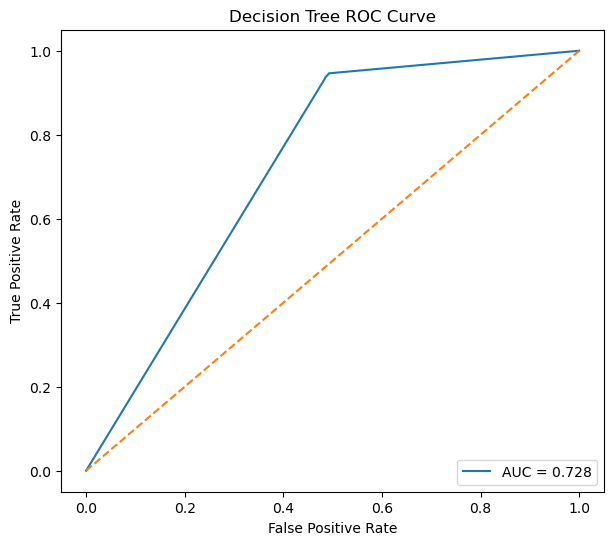

In [46]:
from sklearn.metrics import roc_curve, auc

DT_prob = DT.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    DT_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend(loc="lower right")

print("Decision Tree ROC AUC = %.3f" % roc_auc)
plt.show()

# random forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
RF = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RF.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
RF_predict = RF.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, RF_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        RF_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9400544959128065

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.7019    0.5615    0.6239       130
      Active     0.9582    0.9768    0.9674      1338

    accuracy                         0.9401      1468
   macro avg     0.8301    0.7692    0.7957      1468
weighted avg     0.9355    0.9401    0.9370      1468



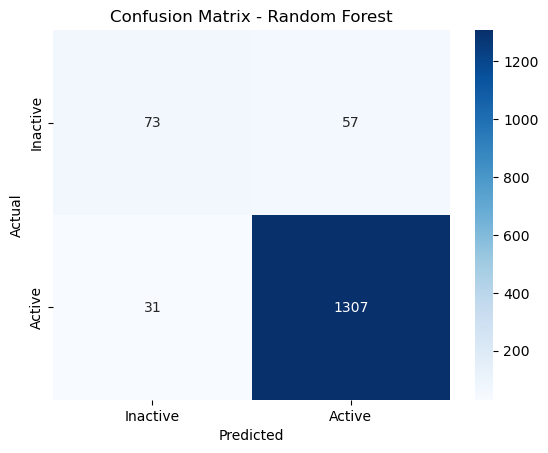

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    RF_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Random Forest ROC AUC = 0.913


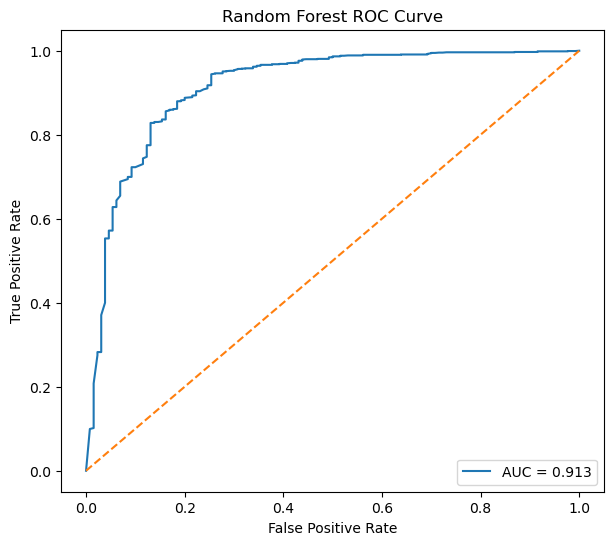

In [52]:
from sklearn.metrics import roc_curve, auc

RF_prob = RF.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    RF_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

print("Random Forest ROC AUC = %.3f" % roc_auc)

plt.show()

# XGBOOST

In [53]:
from xgboost import XGBClassifier

In [54]:
XGB = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

XGB.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [55]:
XGB_predict = XGB.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, XGB_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        XGB_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9352861035422343

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6733    0.5231    0.5887       130
      Active     0.9546    0.9753    0.9649      1338

    accuracy                         0.9353      1468
   macro avg     0.8140    0.7492    0.7768      1468
weighted avg     0.9297    0.9353    0.9316      1468



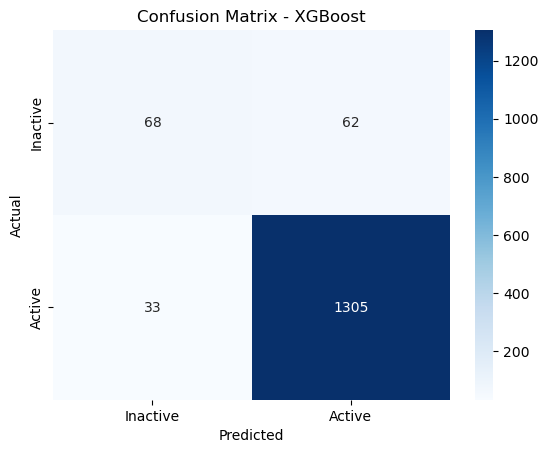

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    XGB_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

XGBoost ROC AUC = 0.925


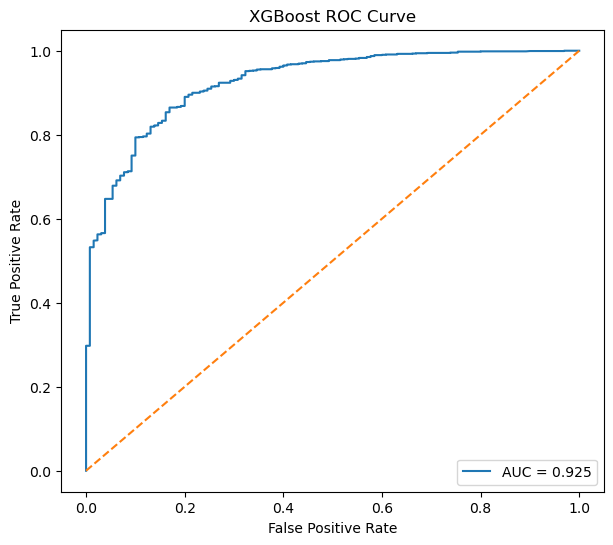

In [58]:
from sklearn.metrics import roc_curve, auc

XGB_prob = XGB.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    XGB_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend(loc="lower right")

print("XGBoost ROC AUC = %.3f" % roc_auc)

plt.show()

In [59]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# SMOTE + Random Forest
rfecv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", rf_model)
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RFECV
rfecv = RFECV(
    estimator=rfecv_pipeline,
    step=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=10,
    importance_getter="named_steps.rf.feature_importances_"
)

# Run RFECV ONLY on training data
rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 1260


In [60]:
selected_features = X_train.columns[rfecv.support_]

selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    "rfecv_selected_featuresBACE1.csv",
    index=False
)

print("Selected features saved:", len(selected_features))

Selected features saved: 1260


In [61]:
import pandas as pd

# 1. Load the same external dataset
external_df = pd.read_csv("atompair_addedBrain.csv")

# 2. Load BACE1 selected features
selected_df = pd.read_csv(
    "rfecv_selected_featuresBACE1.csv"
)

selected_features = selected_df["feature"].tolist()

print("BACE1 selected features:", len(selected_features))

# 3. Check that all selected features exist
missing_features = [
    f for f in selected_features
    if f not in external_df.columns
]

print("Missing features:", len(missing_features))

if missing_features:
    print(missing_features[:20])
else:
    print("✅ All 1260 BACE1 features are available.")

# 4. Keep ONLY the 1260 selected features
X_external_BACE1 = external_df[selected_features]

print("External BACE1 matrix:", X_external_BACE1.shape)

BACE1 selected features: 1260
Missing features: 0
✅ All 1260 BACE1 features are available.
External BACE1 matrix: (77, 1260)


In [62]:
import os

print("BACE1 model files in current folder:")

for f in os.listdir():
    if "bace1" in f.lower() and (f.endswith(".pkl") or f.endswith(".joblib")):
        print(f)

BACE1 model files in current folder:


In [63]:
# Find trained model variables currently available in this notebook

[name for name, obj in globals().items()
 if "bace" in name.lower() or "rf" in name.lower() or "model" in name.lower()]

['RF',
 'RF_predict',
 'RF_prob',
 'RFECV',
 'rf_model',
 'rfecv_pipeline',
 'rfecv',
 'X_external_BACE1']

In [64]:
print("RF:")
print(type(RF))

print("\nrf_model:")
print(type(rf_model))

print("\nRFECV:")
print(type(RFECV))

print("\nrfecv:")
print(type(rfecv))

print("\nrfecv_pipeline:")
print(type(rfecv_pipeline))

RF:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

rf_model:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

RFECV:
<class 'abc.ABCMeta'>

rfecv:
<class 'sklearn.feature_selection._rfe.RFECV'>

rfecv_pipeline:
<class 'imblearn.pipeline.Pipeline'>


In [65]:
print("RF n_features:", getattr(RF, "n_features_in_", "Not available"))
print("rf_model n_features:", getattr(rf_model, "n_features_in_", "Not available"))
print("rfecv n_features:", getattr(rfecv, "n_features_in_", "Not available"))

RF n_features: 1960
rf_model n_features: Not available
rfecv n_features: 1960


In [66]:
# Check the RFECV pipeline structure

print(rfecv_pipeline)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [67]:
print("RFECV selected features:", rfecv.n_features_)
print("RFECV original features:", rfecv.n_features_in_)

RFECV selected features: 1260
RFECV original features: 1960


In [68]:
# ============================================
# BACE1: APPLY THE SAME RFECV SELECTION
# ============================================

# Get the original 1,960 features used during BACE1 training
original_features = X_train.columns.tolist()

# Apply those same 1,960 features to the external dataset
X_external_BACE1_full = external_df[original_features]

print("External original matrix:", X_external_BACE1_full.shape)

# Use the fitted RFECV selector
X_external_BACE1_selected = rfecv.transform(
    X_external_BACE1_full
)

print("External selected matrix:", X_external_BACE1_selected.shape)

External original matrix: (77, 1960)
External selected matrix: (77, 1260)


In [70]:
# Check the RFECV final estimator

bace1_selected_rf = rfecv.estimator_

print("Model type:", type(bace1_selected_rf))
print("Features expected by final RF:", bace1_selected_rf.n_features_in_)
print("Features selected by RFECV:", rfecv.n_features_)

Model type: <class 'imblearn.pipeline.Pipeline'>
Features expected by final RF: 1260
Features selected by RFECV: 1260


In [71]:
# ============================================
# BACE1 prediction using the 1260 selected features
# ============================================

BACE1_prediction = bace1_selected_rf.predict(
    X_external_BACE1_selected
)

BACE1_probability = bace1_selected_rf.predict_proba(
    X_external_BACE1_selected
)[:, 1]

print("✅ BACE1 prediction completed")
print("Compounds predicted:", len(BACE1_prediction))

✅ BACE1 prediction completed
Compounds predicted: 77


In [72]:
# ============================================
# BACE1 - TOP 20 UNIQUE HITS
# ============================================

# Start with the complete external dataset
BACE1_results = external_df.copy()

# Add prediction and probability
BACE1_results["Prediction"] = BACE1_prediction
BACE1_results["Probability"] = BACE1_probability

# Rank highest probability first
BACE1_results = BACE1_results.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

# Remove exact duplicate SMILES
BACE1_unique = BACE1_results.drop_duplicates(
    subset="smiles",
    keep="first"
).reset_index(drop=True)

# Select 20 highest-scoring UNIQUE compounds
top20_BACE1 = BACE1_unique.head(20).copy()

# Add rank
top20_BACE1.insert(
    0,
    "Rank",
    range(1, len(top20_BACE1) + 1)
)

print("Original compounds:", len(BACE1_results))
print("Unique compounds:", len(BACE1_unique))
print("FINAL BACE1 TOP 20:", len(top20_BACE1))

# Display important columns
display(
    top20_BACE1[
        ["Rank", "smiles", "Prediction", "Probability"]
    ]
)

Original compounds: 77
Unique compounds: 56
FINAL BACE1 TOP 20: 20


,Rank,smiles,Prediction,Probability
0,1,N#Cc1ccc2c(c1)CO[C@@]2(CCCN)c1ccc(F)cc1,1,0.825000
1,2,COc1ccc(/C(=C\F)CN)cc1OC,1,0.715000
2,3,CNCCC[C@](C#N)(c1ccc(OC)c(OC)c1)C(C)C,1,0.695000
3,4,COc1ccc2c3c1O[C@H]1[C@@H](O)CC[C@H]4[C@@H](C2)NCC[C@@]341,1,0.665000
4,5,CNCCCC(C#N)(c1ccc(O)c(OC)c1)C(C)C,1,0.630000
5,6,COc1cc2c(cc1OC)C(=O)C(CC1CCNCC1)C2,1,0.628750
6,7,COc1cc(C[C@@H](C)N)c(OC)cc1C,1,0.621429
7,8,OCCCOc1cccc(CN2CCCCC2O)c1,1,0.615000
8,9,CC[C@H](N)Cc1cc(OC)c(C)cc1OC,1,0.603095
9,10,CC[C@@H](N)Cc1cc(OC)c(C)cc1OC,1,0.603095


In [73]:
# ============================================
# FINAL BACE1 TOP 20 - ALL UNIQUE COMPOUNDS
# ============================================

# Start with all 77 predicted compounds
BACE1_results = external_df.copy()

# Add prediction and probability
BACE1_results["Prediction"] = BACE1_prediction
BACE1_results["Probability"] = BACE1_probability

# Highest probability first
BACE1_results = BACE1_results.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

# Remove exact duplicate SMILES
BACE1_unique = BACE1_results.drop_duplicates(
    subset="smiles",
    keep="first"
).reset_index(drop=True)

# Take highest-scoring 20 UNIQUE compounds
top20_BACE1 = BACE1_unique.head(20).copy()

# Add rank
top20_BACE1.insert(
    0,
    "Rank",
    range(1, len(top20_BACE1) + 1)
)

print("Original compounds:", len(BACE1_results))
print("Unique compounds:", len(BACE1_unique))
print("FINAL UNIQUE TOP 20:", len(top20_BACE1))

# Check SMILES duplicates
print(
    "Duplicate SMILES in final:",
    top20_BACE1["smiles"].duplicated().sum()
)

display(
    top20_BACE1[
        ["Rank", "smiles", "Prediction", "Probability"]
    ]
)

Original compounds: 77
Unique compounds: 56
FINAL UNIQUE TOP 20: 20
Duplicate SMILES in final: 0


,Rank,smiles,Prediction,Probability
0,1,N#Cc1ccc2c(c1)CO[C@@]2(CCCN)c1ccc(F)cc1,1,0.825000
1,2,COc1ccc(/C(=C\F)CN)cc1OC,1,0.715000
2,3,CNCCC[C@](C#N)(c1ccc(OC)c(OC)c1)C(C)C,1,0.695000
3,4,COc1ccc2c3c1O[C@H]1[C@@H](O)CC[C@H]4[C@@H](C2)NCC[C@@]341,1,0.665000
4,5,CNCCCC(C#N)(c1ccc(O)c(OC)c1)C(C)C,1,0.630000
5,6,COc1cc2c(cc1OC)C(=O)C(CC1CCNCC1)C2,1,0.628750
6,7,COc1cc(C[C@@H](C)N)c(OC)cc1C,1,0.621429
7,8,OCCCOc1cccc(CN2CCCCC2O)c1,1,0.615000
8,9,CC[C@H](N)Cc1cc(OC)c(C)cc1OC,1,0.603095
9,10,CC[C@@H](N)Cc1cc(OC)c(C)cc1OC,1,0.603095


In [74]:
# Save FINAL BACE1 Top 20 with ALL columns

top20_BACE1.to_excel(
    "TOP20_BACE1_Hits_Final.xlsx",
    index=False,
    engine="openpyxl"
)

print("✅ FINAL BACE1 TOP 20 SAVED")
print("Rows:", len(top20_BACE1))
print("Columns:", len(top20_BACE1.columns))
print("File: TOP20_BACE1_Hits_Final.xlsx")

✅ FINAL BACE1 TOP 20 SAVED
Rows: 20
Columns: 3100
File: TOP20_BACE1_Hits_Final.xlsx


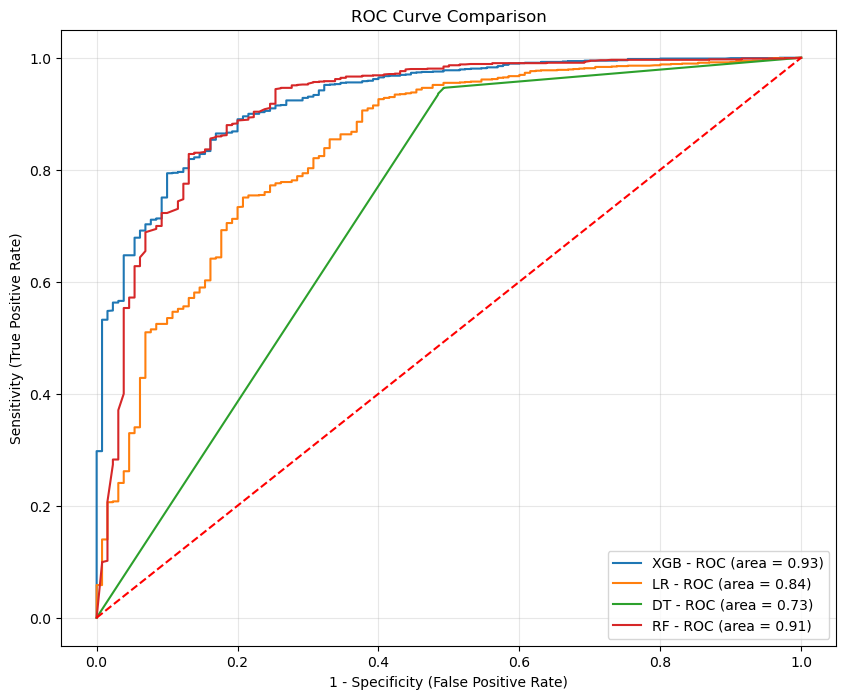

Logistic Regression AUC: 0.842
Decision Tree AUC: 0.728
Random Forest AUC: 0.913
XGBoost AUC: 0.925


In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions for each model
LR_prob = LR.predict_proba(X_test_scaled)[:, 1]
DT_prob = DT.predict_proba(X_test)[:, 1]
RF_prob = RF.predict_proba(X_test)[:, 1]
XGB_prob = XGB.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_LR, tpr_LR, _ = roc_curve(y_test, LR_prob)
fpr_DT, tpr_DT, _ = roc_curve(y_test, DT_prob)
fpr_RF, tpr_RF, _ = roc_curve(y_test, RF_prob)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, XGB_prob)



# Calculate AUC
auc_LR = auc(fpr_LR, tpr_LR)
auc_DT = auc(fpr_DT, tpr_DT)
auc_RF = auc(fpr_RF, tpr_RF)
auc_XGB = auc(fpr_XGB, tpr_XGB)


# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_XGB, tpr_XGB,
     label="XGB - ROC (area = %.2f)" % auc_XGB
)

plt.plot(
     fpr_LR, tpr_LR,
    label="LR - ROC (area = %.2f)" % auc_LR
)

plt.plot(
    fpr_DT, tpr_DT,
    label="DT - ROC (area = %.2f)" % auc_DT
)

plt.plot(
    fpr_RF, tpr_RF,
    label="RF - ROC (area = %.2f)" % auc_RF
)


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    "r--"
)

plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)
plt.show()


# Print AUC values
print("Logistic Regression AUC:", round(auc_LR, 3))
print("Decision Tree AUC:", round(auc_DT, 3))
print("Random Forest AUC:", round(auc_RF, 3))
print("XGBoost AUC:", round(auc_XGB, 3))